# 🏗️ Python Practice: Clustering & Dimensionality Reduction with scikit-learn

Welcome to your Machine Learning practice notebook on **clustering and dimensionality reduction**! 🎉  

This notebook will guide you through the fundamentals of **unsupervised learning**, using the Digits dataset. You will explore clustering algorithms, evaluate their performance, and visualize high-dimensional data in lower dimensions.

By the end, you will have hands-on experience with:  
- K-Means clustering  
- Gaussian Mixture Models (GMM)  
- Principal Component Analysis (PCA)  
- t-SNE visualization  
- Comparing cluster quality with metrics such as **ARI**, **Silhouette Score**, and **BIC**  
- Interpreting PCA components for feature importance  

---

## 🧭 Instructions
- This notebook contains **8 exercises**.  
- Each task focuses on an essential step of clustering or dimensionality reduction: data exploration, model fitting, evaluation, visualization, and interpretation.  
- Some exercises include **questions you need to answer**. For these, **create a new Markdown cell below the question cell and write your answers there**.  
- Hints are available if you get stuck — take your time and explore!  
- You can run the tests as many times as needed.  
- Total estimated time: **90–120 minutes**.  

---

## 🧠 Concepts Covered
- Loading datasets into Pandas and visualizing them  
- K-Means and Gaussian Mixture Models (GMM) clustering  
- Clustering evaluation: **Adjusted Rand Index (ARI)**, **Silhouette Score**, **BIC**  
- PCA for dimensionality reduction and component interpretation  
- t-SNE for non-linear visualization  
- Comparing clustering methods and visual embeddings  
- Understanding variance and feature importance in PCA  

---

Let’s start your journey into **clustering and dimensionality reduction**! 🚀

## 🧩 Theory Recap: Clustering & Dimensionality Reduction

**Clustering and dimensionality reduction** are key techniques in **unsupervised learning**, where we work with data **without labeled outcomes**.  
The goal is to **discover patterns, groups, or structure** in the data.

---

### ⚙️ Unsupervised Learning

Unlike supervised learning:
- There are **no labels** to guide the model.  
- The algorithm tries to **find natural groupings or structures** in the data.  
- Clustering and dimensionality reduction are two common tasks:

| Task | Purpose |
|:-----|:--------|
| **Clustering** | Group similar data points into clusters |
| **Dimensionality Reduction** | Reduce the number of features while retaining most information |

---

### 🟢 K-Means Clustering

**K-Means** is a simple and widely used clustering algorithm.

#### How it works:
1. Choose the number of clusters $k$.  
2. Randomly initialize $k$ cluster centroids.  
3. Assign each data point to the nearest centroid.  
4. Recompute centroids as the mean of assigned points.  
5. Repeat until assignments no longer change.

#### Key ideas:
- Finds **spherical, equally sized clusters**.  
- Sensitive to **initialization** and **feature scaling**.  
- Easy to interpret and visualize in low dimensions.

---

### 🌫️ Gaussian Mixture Models (GMM)

**GMM** is a probabilistic clustering method.  
It assumes data points are generated from a mixture of **Gaussian distributions**.

#### How it works:
- Each cluster is represented by a **Gaussian distribution** (mean and covariance).  
- Each point has a **probability of belonging** to each cluster.  
- Uses **Expectation-Maximization (EM)** to estimate cluster parameters.

#### Key ideas:
- Can model **elliptical clusters** and overlapping distributions.  
- Provides **soft cluster assignments** (probabilities) rather than hard labels.  

---

### 📉 Principal Component Analysis (PCA)

**PCA** is a technique to reduce the **dimensionality** of data while retaining most variance.

#### How it works:
1. Find new axes (**principal components**) that capture the **largest variance**.  
2. Project data onto these components to reduce dimensions.  
3. Components are **linear combinations of original features**.

#### Key ideas:
- Helps visualize high-dimensional data in 2D or 3D.  
- Can reveal **feature importance**.  
- Often used **before clustering** to reduce noise and improve efficiency.

---

### 🔄 t-SNE (t-distributed Stochastic Neighbor Embedding)

**t-SNE** is a **non-linear dimensionality reduction** technique, ideal for visualization.

#### How it works:
- Preserves **local structure** (similar points stay close) while mapping high-dimensional data to 2D or 3D.  
- Highlights **clusters** in a visual embedding, even when clusters are complex or non-linear.

#### Key ideas:
- Excellent for **visual exploration** of high-dimensional data.  
- Not suitable for downstream tasks like clustering (used mostly for plotting).  

---

### 🌍 Real-Life Applications

- **Customer segmentation** → identify groups with similar buying habits  
- **Image analysis** → group images by similarity without labels  
- **Genomics** → cluster genes or patients based on expression patterns  
- **Anomaly detection** → detect outliers or unusual patterns  
- **Feature reduction** → compress data before machine learning or visualization  

---

### 💡 Key Takeaways

- **Clustering** finds **hidden groups** in unlabeled data.  
- **K-Means** → simple, hard clusters, works best for spherical groups.  
- **GMM** → probabilistic, soft clusters, handles overlapping and elliptical clusters.  
- **PCA** → linear reduction of dimensions, captures variance, aids visualization.  
- **t-SNE** → non-linear reduction, preserves local structure, excellent for visualizing complex patterns.  
- Proper **scaling** and **preprocessing** are important for both clustering and dimensionality reduction.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Exercise 1: Exploratory Data Analysis

In this task, you will load the famous **Digits dataset**, which contains 1,797 samples of handwritten digits (0–9).  
Each sample has 64 features, corresponding to the 8×8 grayscale pixel values of the image.  

#### Your tasks:
- Load the Digits dataset using `sklearn.datasets.load_digits`.  
- Convert it into a Pandas DataFrame for easier exploration.  
- Display the **shape** of the dataset and the first few rows.  
- Show the **class distribution** with a bar plot.  
- Use `.describe()` to compute summary statistics of the features.  
- Plot the first 5 digits as images.  

This step is important because **understanding the dataset** is the foundation for applying machine learning models correctly.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li>Use <code>from sklearn.datasets import load_digits</code> to load the data.</li>
      <li>Convert it into a DataFrame using <code>pd.DataFrame(digits.data)</code>.</li>
      <li>The target labels can be found in <code>digits.target</code>.</li>
      <li>Use <code>value_counts()</code> to check class distribution.</li>
      <li>For plotting a bar chart of class counts, try <code>matplotlib.pyplot.bar</code> or <code>seaborn.countplot</code>.</li>
      <li>To visualize a digit image, reshape the row vector to 8×8 and use <code>plt.imshow()</code>.</li>
    </ul>
</details>

X shape: (1797, 64)
shape: (1797, 65)
y shape: (1797,)

First 5 rows:
    0    1    2     3     4     5    6    7    8    9   ...   54   55   56  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  5.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  9.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    57   58    59    60    61   62   63  
0  0.0  6.0  13.0  10.0   0.0  0.0  0.0  
1  0.0  0.0  11.0  16.0  10.0  0.0  0.0  
2  0.0  0.0   3.0  11.0  16.0  9.0  0.0  
3  0.0  7.0  13.0  13.0   9.0  0.0  0.0  
4  0.0  0.0   2.0  16.0   4.0  0.0  0.0  

[5 rows x 64 columns]

Class distribution:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


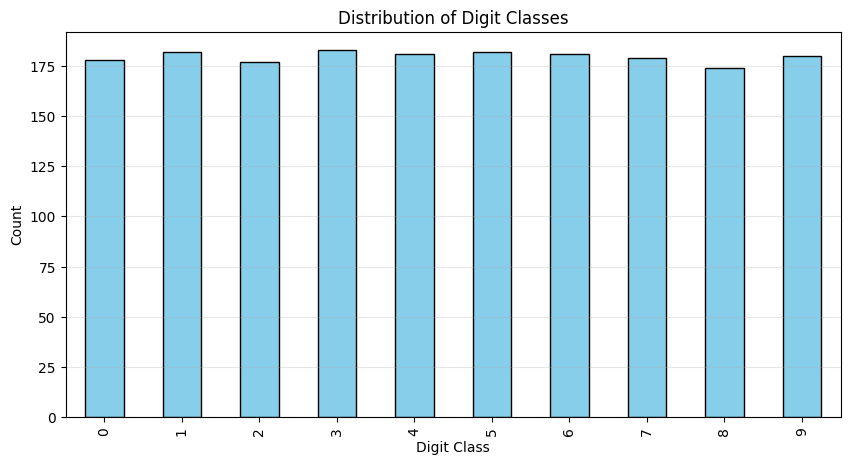


Summary statistics:
           0            1            2            3            4   \
count  1797.0  1797.000000  1797.000000  1797.000000  1797.000000   
mean      0.0     0.303840     5.204786    11.835838    11.848080   
std       0.0     0.907192     4.754826     4.248842     4.287388   
min       0.0     0.000000     0.000000     0.000000     0.000000   
25%       0.0     0.000000     1.000000    10.000000    10.000000   
50%       0.0     0.000000     4.000000    13.000000    13.000000   
75%       0.0     0.000000     9.000000    15.000000    15.000000   
max       0.0     8.000000    16.000000    16.000000    16.000000   

                5            6            7            8            9   ...  \
count  1797.000000  1797.000000  1797.000000  1797.000000  1797.000000  ...   
mean      5.781859     1.362270     0.129661     0.005565     1.993879  ...   
std       5.666418     3.325775     1.037383     0.094222     3.196160  ...   
min       0.000000     0.000000     0.000

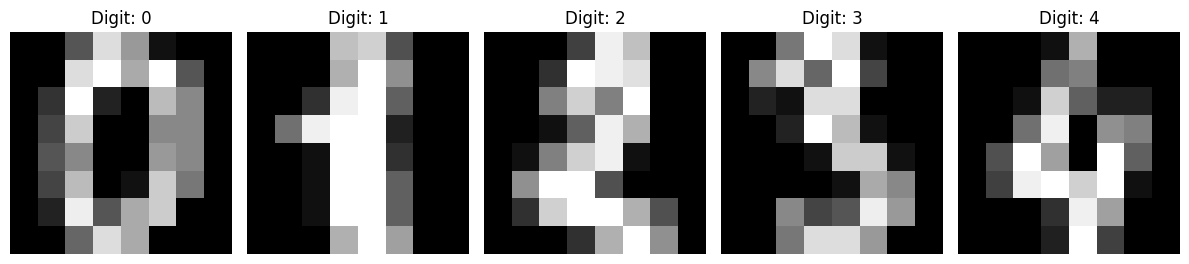

In [2]:
# Exercise 1: Exploratory Data Analysis
from sklearn.datasets import load_digits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Digits dataset
digits = load_digits()

# Convert to DataFrame
X = pd.DataFrame(digits.data)
y = pd.Series(digits.target)

# Create df with target column
df = X.copy()
df['target'] = y

# Get shape and class counts
shape = df.shape
class_counts = y.value_counts().sort_index()

# Display shape and first rows
print(f"X shape: {X.shape}")
print(f"shape: {shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst 5 rows:")
print(X.head())

# Class distribution
print(f"\nClass distribution:")
print(y.value_counts().sort_index())

# Bar plot
plt.figure(figsize=(10, 5))
y.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.title('Distribution of Digit Classes')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Summary statistics
print(f"\nSummary statistics:")
print(X.describe())

# Plot first 5 digits as images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    ax = axes[i]
    image = digits.images[i]
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Digit: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
### BEGIN TESTS
assert shape == (1797, 65)
assert set(df["target"].unique()) == set(range(10))
assert class_counts.sum() == 1797
assert all((X.dtypes == float) | (X.dtypes == int))
assert df.iloc[0, 0] == digits.data[0, 0]
### END TESTS

### Questions
1. How many classes do we have in the Digits dataset?  
2. Are the classes balanced? How can you tell?  
3. What type of features do we have in this dataset (continuous, ordinal, or categorical)?    
4. Why is it useful to plot some sample images before applying clustering or dimensionality reduction?

## Exercise 2: K-Means Clustering with Multiple k

In this task, you will apply **K-Means clustering** to the Digits dataset for different numbers of clusters.  

#### Your tasks:
- Fit **K-Means models** for `k = 5, 10, 15`.  
- Assign each sample to a cluster and store the labels.  
- Compute the **Adjusted Rand Index (ARI)** comparing cluster labels with the true labels.  
- Compute the **Silhouette Score** for each clustering.  
- Compare ARI and Silhouette scores for the different k values.  

**About the metrics**:  
- **Adjusted Rand Index (ARI)**: measures agreement between clustering and true labels (1 = perfect, 0 = random, <0 = worse than random).  
  - **Note:** ARI can be computed even if the number of clusters \(k\) is different from the true number of classes. It evaluates agreement by looking at **pairs of samples** and how consistently they are clustered together in both the predicted and true labels.  
- **Silhouette Score**: measures how similar a sample is to its own cluster compared to other clusters (range -1 to 1; higher = better).  

This exercise helps you understand **unsupervised clustering evaluation** and how cluster quality changes with k.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li>Use <code>from sklearn.cluster import KMeans</code> for clustering.</li>
      <li>Use <code>fit_predict</code> to get cluster labels for each sample.</li>
      <li>Import <code>adjusted_rand_score</code> and <code>silhouette_score</code> from <code>sklearn.metrics</code>.</li>
      <li>Loop over the different k values, store cluster labels, ARI, and Silhouette scores in lists or dictionaries.</li>
      <li>Compare the metrics to see which k gives the best clustering quality.</li>
    </ul>
</details>

In [3]:
# Exercise 2: K-Means Clustering with Multiple k Values
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Test different k values
k_values = [5, 10, 15]
kmeans_results = []
ari_scores = {}
silhouette_scores = {}
cluster_labels_dict = {}

for k in k_values:
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred_kmeans = kmeans.fit_predict(X)
    
    # Compute ARI and Silhouette Score
    ari = adjusted_rand_score(y, y_pred_kmeans)
    silhouette = silhouette_score(X, y_pred_kmeans)
    
    # Store in dictionaries
    ari_scores[k] = ari
    silhouette_scores[k] = silhouette
    cluster_labels_dict[k] = y_pred_kmeans
    
    kmeans_results.append({
        'k': k,
        'ARI': ari,
        'Silhouette Score': silhouette
    })
    
    print(f"K-Means with k={k}:")
    print(f"  Adjusted Rand Index: {ari:.4f}")
    print(f"  Silhouette Score: {silhouette:.4f}\n")

# Create results DataFrame
kmeans_df = pd.DataFrame(kmeans_results)
print("=" * 50)
print("K-MEANS CLUSTERING RESULTS")
print("=" * 50)
print(kmeans_df.to_string(index=False))

K-Means with k=5:
  Adjusted Rand Index: 0.3575
  Silhouette Score: 0.1362

K-Means with k=10:
  Adjusted Rand Index: 0.6669
  Silhouette Score: 0.1824

K-Means with k=15:
  Adjusted Rand Index: 0.6949
  Silhouette Score: 0.1864

K-MEANS CLUSTERING RESULTS
 k      ARI  Silhouette Score
 5 0.357506          0.136208
10 0.666912          0.182385
15 0.694894          0.186440


In [5]:
### BEGIN TESTS
assert set(ari_scores.keys()) == {5, 10, 15}
assert all(0 <= val <= 1 for val in ari_scores.values())
assert set(silhouette_scores.keys()) == {5, 10, 15}
assert all(-1 <= val <= 1 for val in silhouette_scores.values())
assert cluster_labels_dict[10].shape[0] == X.shape[0]
### END TESTS

### Questions
1. Which value of k gave the highest ARI? Which gave the highest Silhouette score?  
2. Do ARI and Silhouette score always agree on the best k? Why or why not?   

## Exercise 3: Gaussian Mixture Models (GMM) Clustering

In this task, you will apply **Gaussian Mixture Models (GMM)** to the Digits dataset. GMM is a probabilistic clustering method that models the data as a mixture of Gaussian distributions.  

#### Your tasks:
- Fit **GMM models** for `n_components = 5, 10, 15`.  
- Assign each sample to a cluster using the **predict()** method.  
- Compute the **Adjusted Rand Index (ARI)** comparing cluster labels with true labels.  
- Compute the **Silhouette Score** for each clustering.  
- Compare the clustering performance for different numbers of components.  

**About GMM**:  
- GMM assumes data is generated from a mixture of Gaussian distributions.  
- Each component has its own mean and covariance matrix.  
- Unlike K-Means, GMM can capture **elliptical clusters** and provides **soft probabilities** of membership.  
- ARI can be computed even if the number of components differs from the true number of classes.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li>Use <code>from sklearn.mixture import GaussianMixture</code>.</li>
      <li>Use <code>predict()</code> to get cluster assignments.</li>
      <li>Compute <code>adjusted_rand_score</code> and <code>silhouette_score</code> as in Exercise 2.</li>
      <li>Loop over different <code>n_components</code> and store results in dictionaries for comparison.</li>
      <li>You can also inspect <code>gmm.weights_</code> and <code>gmm.means_</code> for extra insights.</li>
    </ul>
</details>

In [4]:
# Exercise 3: Gaussian Mixture Models Clustering
from sklearn.mixture import GaussianMixture

# Test different n_components values
n_components = [5, 10, 15]
gmm_results = []
ari_scores_gmm = {}
silhouette_scores_gmm = {}
cluster_labels_gmm = {}

for n in n_components:
    # Fit GMM
    gmm = GaussianMixture(n_components=n, random_state=42)
    y_pred_gmm = gmm.fit_predict(X)
    
    # Compute ARI and Silhouette Score
    ari = adjusted_rand_score(y, y_pred_gmm)
    silhouette = silhouette_score(X, y_pred_gmm)
    
    # Store in dictionaries
    ari_scores_gmm[n] = ari
    silhouette_scores_gmm[n] = silhouette
    cluster_labels_gmm[n] = y_pred_gmm
    
    gmm_results.append({
        'n_components': n,
        'ARI': ari,
        'Silhouette Score': silhouette
    })
    
    print(f"GMM with n_components={n}:")
    print(f"  Adjusted Rand Index: {ari:.4f}")
    print(f"  Silhouette Score: {silhouette:.4f}\n")

# Create results DataFrame
gmm_df = pd.DataFrame(gmm_results)
print("=" * 50)
print("GAUSSIAN MIXTURE MODELS CLUSTERING RESULTS")
print("=" * 50)
print(gmm_df.to_string(index=False))

d:\python 3.12.9\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


GMM with n_components=5:
  Adjusted Rand Index: 0.2802
  Silhouette Score: 0.0925

GMM with n_components=10:
  Adjusted Rand Index: 0.7021
  Silhouette Score: 0.1530

GMM with n_components=15:
  Adjusted Rand Index: 0.6898
  Silhouette Score: 0.1637

GAUSSIAN MIXTURE MODELS CLUSTERING RESULTS
 n_components      ARI  Silhouette Score
            5 0.280219          0.092516
           10 0.702063          0.153030
           15 0.689786          0.163683


In [5]:
### BEGIN TESTS
assert set(ari_scores_gmm.keys()) == {5, 10, 15}
assert all(0 <= val <= 1 for val in ari_scores_gmm.values())
assert set(silhouette_scores_gmm.keys()) == {5, 10, 15}
assert all(-1 <= val <= 1 for val in silhouette_scores_gmm.values())
assert cluster_labels_gmm[10].shape[0] == X.shape[0]
### END TESTS

### Questions
1. How do ARI and Silhouette scores for GMM compare with those for K-Means (from Exercise 2)?  
2. How does increasing the number of components affect clustering performance?  

## Exercise 4: Principal Component Analysis (PCA)

In this task, you will apply **Principal Component Analysis (PCA)** to the Digits dataset to reduce dimensionality.  

#### Your tasks:
- Fit PCA to the Digits dataset.  
- Determine the number of components needed to **explain at least 90% of the variance**.  
- Transform the data to the selected number of components.  
- Plot the **cumulative explained variance ratio**.  
- Optionally, visualize the first 2 principal components in a scatter plot colored by true labels.  

**About PCA**:  
- PCA finds new axes (principal components) that **maximize variance**.  
- The first component explains the most variance, the second explains the next most, and so on.  
- Dimensionality reduction can help with **visualization, noise reduction, and faster modeling**.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li>Use <code>from sklearn.decomposition import PCA</code>.</li>
      <li>Use <code>pca.explained_variance_ratio_</code> to get variance explained by each component.</li>
      <li>Use <code>np.cumsum(...)</code> to compute cumulative explained variance.</li>
      <li>To select number of components, find the first index where cumulative variance &ge; 0.9.</li>
      <li>Use <code>pca.transform(X)</code> to reduce dimensionality.</li>
      <li>For scatter plots, you can use <code>plt.scatter()</code> and color by labels <code>y</code>.</li>
    </ul>
</details>

Number of components needed for 90% variance: 21
Cumulative variance ratio with 21 components: 0.9032

Original data shape: (1797, 64)
PCA-reduced data shape: (1797, 21)

Explained variance ratio per component (first 10):
  PC1: 0.1489
  PC2: 0.1362
  PC3: 0.1179
  PC4: 0.0841
  PC5: 0.0578
  PC6: 0.0492
  PC7: 0.0432
  PC8: 0.0366
  PC9: 0.0335
  PC10: 0.0308


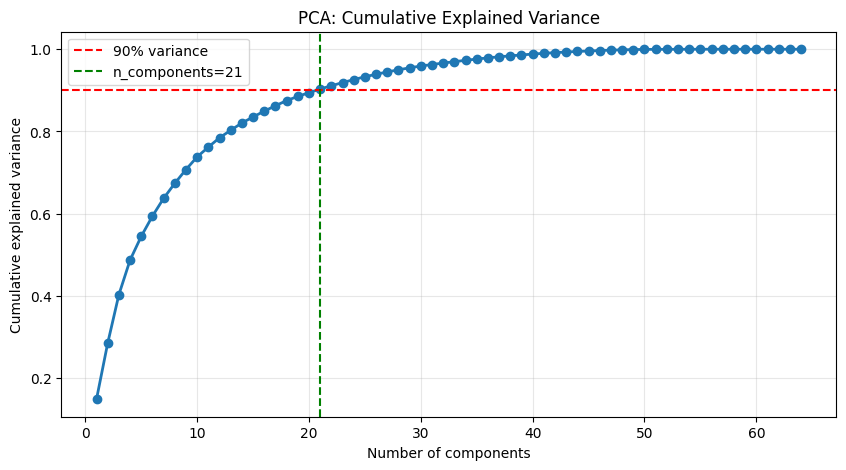

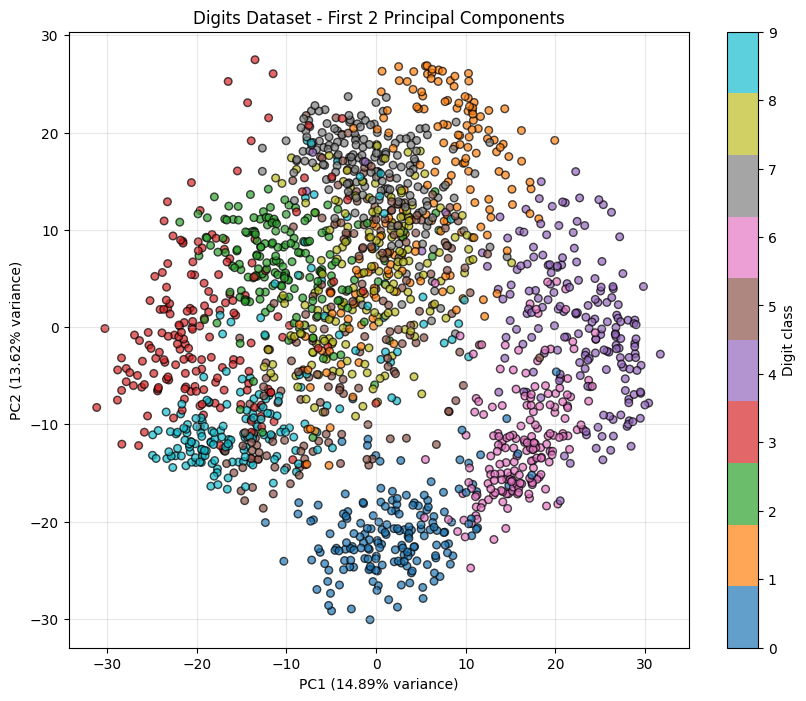

In [6]:
# Exercise 4: Principal Component Analysis (PCA)
from sklearn.decomposition import PCA

# Fit PCA with all components first
pca_full = PCA()
pca_full.fit(X)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find components needed for 90% variance
n_components_90 = np.argmax(cumsum_variance >= 0.90) + 1

print(f"Number of components needed for 90% variance: {n_components_90}")
print(f"Cumulative variance ratio with {n_components_90} components: {cumsum_variance[n_components_90-1]:.4f}\n")

# Fit PCA with selected components
pca = PCA(n_components=n_components_90)
X_pca = pca.fit_transform(X)

print(f"Original data shape: {X.shape}")
print(f"PCA-reduced data shape: {X_pca.shape}")
print(f"\nExplained variance ratio per component (first 10):")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f}")

# Plot cumulative explained variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 'o-', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axvline(x=n_components_90, color='g', linestyle='--', label=f'n_components={n_components_90}')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Scatter plot of first 2 PCs
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=30, alpha=0.7, edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Digits Dataset - First 2 Principal Components')
plt.colorbar(scatter, label='Digit class')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
### BEGIN TESTS
assert X_pca.shape[0] == X.shape[0]
assert n_components_90 <= X.shape[1]
assert np.all(cumsum_variance >= 0)
assert cumsum_variance[-1] <= 1.01
### END TESTS

### Questions
1. How many components are needed to explain at least 90% of the variance?  
2. Why might PCA be useful before clustering or classification?  
3. What does the first principal component represent in terms of variance?  
4. How does reducing dimensions affect visualization and computational cost?

## Exercise 5: t-SNE for Visualization

In this task, you will apply **t-Distributed Stochastic Neighbor Embedding (t-SNE)** to the Digits dataset to visualize high-dimensional data in 2D.  

#### Your tasks:
- Apply t-SNE to the Digits dataset with 2 components.  
- Plot the 2D embedding with points colored by their true digit labels.  
- Experiment with different values of **perplexity** and **learning_rate** to see how the visualization changes.  

**About t-SNE**:
- t-SNE is a **non-linear dimensionality reduction** method optimized for visualization.  
- It preserves **local neighborhoods**: points close in high-dimensional space tend to be close in 2D.  
- **Perplexity** controls the number of effective nearest neighbors; typical values are 5–50.  
- **Learning rate** affects optimization; too small or too large values may distort the embedding.  
- t-SNE is stochastic; results may vary between runs.  
- Unlike PCA, it does not produce a transform for new data; it is mainly for visualization.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li>Use <code>from sklearn.manifold import TSNE</code>.</li>
      <li>Set <code>n_components=2</code> and optionally <code>random_state=42</code> for reproducibility.</li>
      <li>Use <code>tsne.fit_transform(X)</code> to get 2D coordinates.</li>
      <li>Plot using <code>plt.scatter()</code>, coloring points by their digit label <code>y</code>.</li>
      <li>You can adjust <code>perplexity</code> and <code>learning_rate</code> to improve separation.</li>
    </ul>
</details>

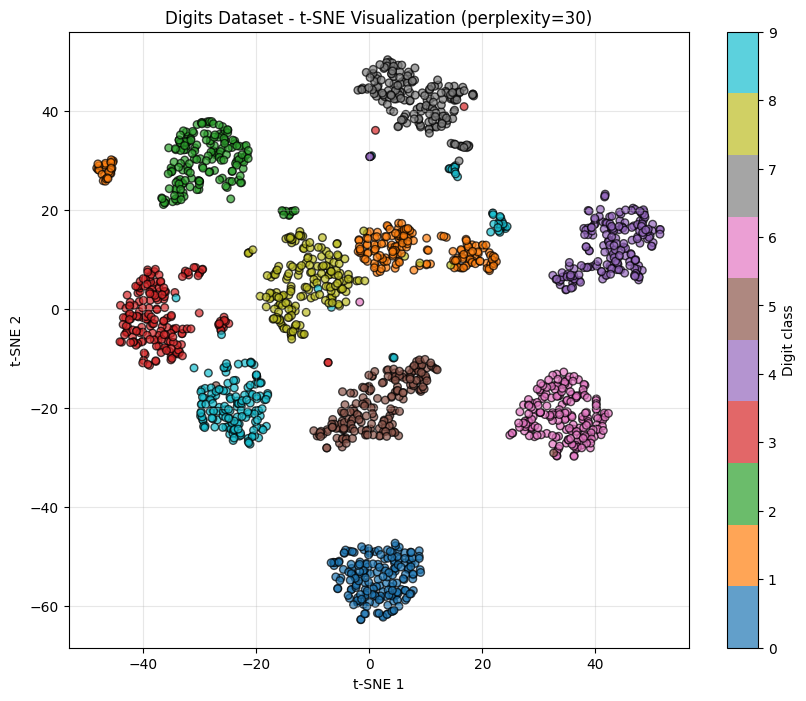

Applying t-SNE with perplexity=50...


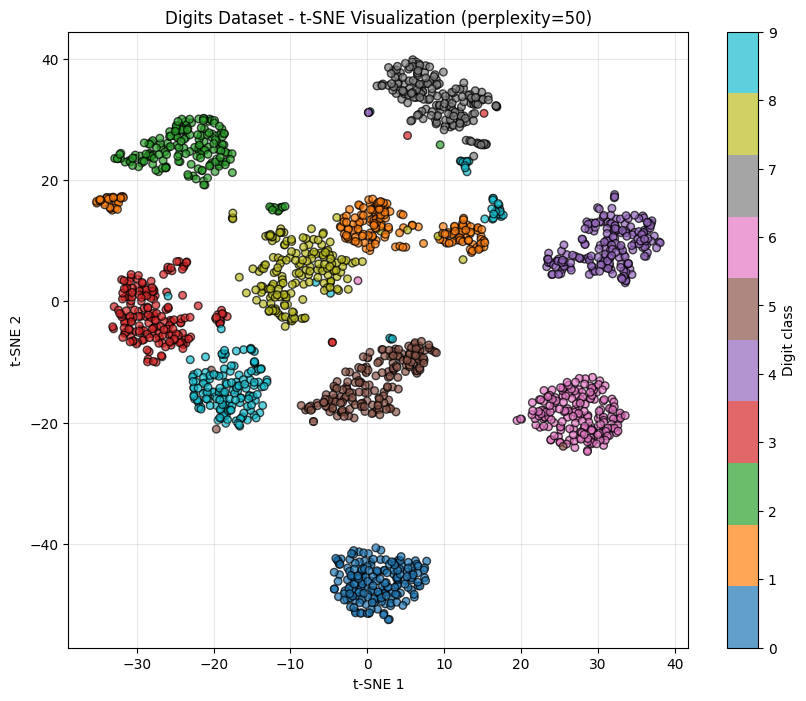


Observation: Higher perplexity tends to preserve more global structure.


In [16]:
# Exercise 5: t-SNE for Visualization
from sklearn.manifold import TSNE

# Apply t-SNE with default parameters
tsne_default = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto', max_iter=1000)
X_tsne = tsne_default.fit_transform(X)
X_tsne_default = X_tsne

# Plot t-SNE with default parameters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=30, alpha=0.7, edgecolors='k')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Digits Dataset - t-SNE Visualization (perplexity=30)')
plt.colorbar(scatter, label='Digit class')
plt.grid(True, alpha=0.3)
plt.show()

# Try with higher perplexity
print("Applying t-SNE with perplexity=50...")
tsne_high_perp = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate='auto', max_iter=1000)
X_tsne_high = tsne_high_perp.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne_high[:, 0], X_tsne_high[:, 1], c=y, cmap='tab10', s=30, alpha=0.7, edgecolors='k')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Digits Dataset - t-SNE Visualization (perplexity=50)')
plt.colorbar(scatter, label='Digit class')
plt.grid(True, alpha=0.3)
plt.show()

print("\nObservation: Higher perplexity tends to preserve more global structure.")

In [8]:
### BEGIN TESTS
assert X_tsne.shape[0] == X.shape[0]
assert X_tsne.shape[1] == 2
assert np.all(np.isfinite(X_tsne))
### END TESTS

### Questions
1. How well does t-SNE separate the different digit classes?  
2. Why is t-SNE mainly used for visualization and not for general dimensionality reduction?  
3. How might the choice of perplexity affect the t-SNE embedding?  

## Exercise 6: Comparing K-Means and GMM on PCA-Reduced Data

In this task, you will compare **K-Means** and **Gaussian Mixture Models (GMM)** clustering on the Digits dataset **after reducing its dimensionality with PCA**.  

#### Your tasks:
- Reduce the Digits dataset to **30 principal components** using PCA.  
- Fit **K-Means** with `n_clusters=10`.  
- Fit **GMM** with `n_components=10`.  
- Compute **Adjusted Rand Index (ARI)** and **Silhouette Score** for both models.  
- Compare performance between K-Means and GMM.  

**About the methods**:  
- K-Means partitions data into clusters by minimizing **within-cluster variance**.  
- GMM assumes data comes from a mixture of **Gaussian distributions**, allowing soft probabilistic assignments.  
- ARI measures agreement with true labels; Silhouette measures cluster cohesion and separation.    

**Interpretation note:**  
- A **higher Silhouette score** indicates tighter, well-separated clusters in terms of geometry.  
- A **higher ARI** indicates better alignment with the true labels.  
- It is possible for **K-Means to have higher Silhouette** but **GMM to have higher ARI** — this occurs because GMM can capture more complex cluster shapes that match the true labels, even if clusters overlap geometrically.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li>Use PCA to reduce dimensionality: <code>PCA(n_components=30)</code> and <code>fit_transform</code>.</li>
      <li>Use <code>KMeans(n_clusters=10, random_state=42)</code> and <code>fit_predict</code>.</li>
      <li>Use <code>GaussianMixture(n_components=10, max_iter=500, n_init=5, random_state=42)</code> and <code>fit_predict</code>.</li>
      <li>Compute <code>adjusted_rand_score(y, labels)</code> and <code>silhouette_score(X_reduced, labels)</code> for both models.</li>
    </ul>
</details>

In [9]:
# Exercise 6: Comparing K-Means and GMM on PCA-Reduced Data
# Reduce to 30 PCs using PCA
pca_30 = PCA(n_components=30)
X_reduced = pca_30.fit_transform(X)

print(f"Variance explained by 30 PCs: {sum(pca_30.explained_variance_ratio_):.4f}\n")

# Fit K-Means with 10 clusters
kmeans_10 = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_kmeans = kmeans_10.fit_predict(X_reduced)

# Fit GMM with 10 components
gmm_10 = GaussianMixture(n_components=10, random_state=42)
labels_gmm = gmm_10.fit_predict(X_reduced)

# Compute metrics
ari_kmeans = adjusted_rand_score(y, labels_kmeans)
silhouette_kmeans = silhouette_score(X_reduced, labels_kmeans)

ari_gmm = adjusted_rand_score(y, labels_gmm)
silhouette_gmm = silhouette_score(X_reduced, labels_gmm)

# Display results
print("=" * 60)
print("CLUSTERING ON PCA-REDUCED DATA (30 components)")
print("=" * 60)
print(f"\nK-Means (n_clusters=10):")
print(f"  Adjusted Rand Index: {ari_kmeans:.4f}")
print(f"  Silhouette Score: {silhouette_kmeans:.4f}")

print(f"\nGaussian Mixture Models (n_components=10):")
print(f"  Adjusted Rand Index: {ari_gmm:.4f}")
print(f"  Silhouette Score: {silhouette_gmm:.4f}")

# Comparison
comparison_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'GMM'],
    'ARI': [ari_kmeans, ari_gmm],
    'Silhouette Score': [silhouette_kmeans, silhouette_gmm]
})

print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))

Variance explained by 30 PCs: 0.9591

CLUSTERING ON PCA-REDUCED DATA (30 components)

K-Means (n_clusters=10):
  Adjusted Rand Index: 0.6685
  Silhouette Score: 0.1939

Gaussian Mixture Models (n_components=10):
  Adjusted Rand Index: 0.7043
  Silhouette Score: 0.1885

COMPARISON
Algorithm      ARI  Silhouette Score
  K-Means 0.668456          0.193903
      GMM 0.704298          0.188463


In [10]:
### BEGIN TESTS
assert X_reduced.shape[1] == 30
assert labels_kmeans.shape[0] == X_reduced.shape[0]
assert labels_gmm.shape[0] == X_reduced.shape[0]
assert 0 <= ari_kmeans <= 1
assert 0 <= ari_gmm <= 1
assert -1 <= silhouette_kmeans <= 1
assert -1 <= silhouette_gmm <= 1
### END TESTS

### Questions
1. Which model (K-Means or GMM) achieved higher ARI and which one achieved higher Silhouette score?  

## Exercise 7: Visualizing Clusters with t-SNE and PCA

In this task, you will visualize the Digits dataset in 2D using both **PCA** and **t-SNE**, and compare how clusters appear.

#### Your tasks:
- Reduce the Digits dataset to **2 dimensions** using PCA and plot a scatter plot colored by true labels.  
- Reduce the dataset using **t-SNE** (n_components=2) and plot a scatter plot colored by true labels.  
- Compare the separation and clustering in the PCA and t-SNE plots.  
- Experiment with **t-SNE parameters** (`perplexity` and `learning_rate`) to see how the embedding changes.  

**Notes:**
- PCA is **linear**, preserves global variance, and may not separate all classes well in 2D.  
- t-SNE is **non-linear**, preserves local neighborhoods, and often produces better visual separation of clusters.  
- This exercise emphasizes **visual evaluation** of clustering results.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li>Use <code>PCA(n_components=2)</code> and <code>fit_transform</code> for the PCA plot.</li>
      <li>Use <code>TSNE(n_components=2, random_state=42)</code> for t-SNE.</li>
      <li>Use <code>plt.scatter()</code> and color points by <code>y</code>.</li>
      <li>Try different <code>perplexity</code> (5–50) and <code>learning_rate</code> values for t-SNE.</li>
    </ul>
</details>

Applying t-SNE (this may take a moment)...


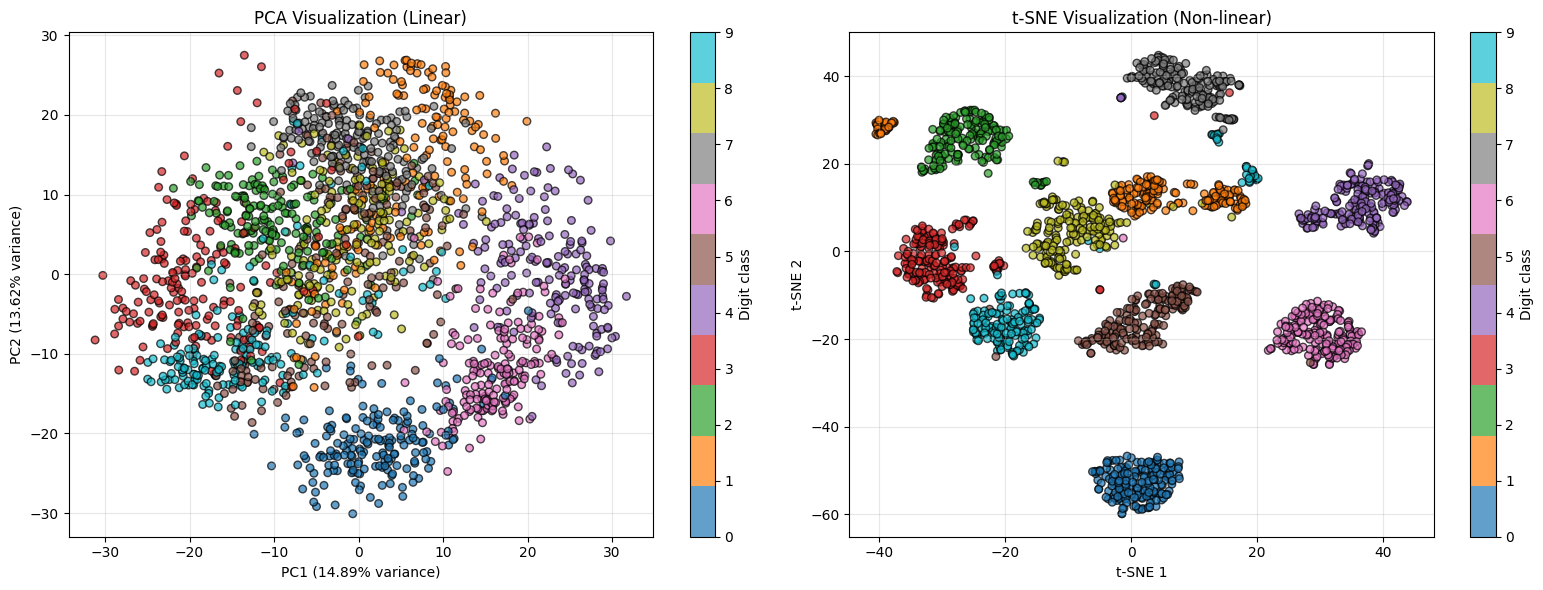


Comparison:
- PCA: Linear transformation, globally preserves structure
- t-SNE: Non-linear transformation, better at separating classes locally


In [11]:
# Exercise 7: Visualizing Clusters with PCA vs t-SNE
# PCA to 2 dimensions
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X)

# t-SNE to 2 dimensions
print("Applying t-SNE (this may take a moment)...")
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=40, learning_rate='auto', max_iter=1000)
X_tsne2 = tsne_2d.fit_transform(X)

# Create comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
scatter1 = ax1.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap='tab10', s=30, alpha=0.7, edgecolors='k')
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
ax1.set_title('PCA Visualization (Linear)')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Digit class')

# t-SNE plot
scatter2 = ax2.scatter(X_tsne2[:, 0], X_tsne2[:, 1], c=y, cmap='tab10', s=30, alpha=0.7, edgecolors='k')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_title('t-SNE Visualization (Non-linear)')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Digit class')

plt.tight_layout()
plt.show()

print("\nComparison:")
print("- PCA: Linear transformation, globally preserves structure")
print("- t-SNE: Non-linear transformation, better at separating classes locally")

In [12]:
### BEGIN TESTS
assert X_pca2.shape == (X.shape[0], 2)
assert X_tsne2.shape == (X.shape[0], 2)
assert np.all(np.isfinite(X_pca2))
assert np.all(np.isfinite(X_tsne2))
### END TESTS

### Questions
1. How do the clusters differ between PCA and t-SNE visualizations?  
2. Why might t-SNE provide better visual separation than PCA in this dataset?   
3. When might PCA be preferred over t-SNE for dimensionality reduction?

## Exercise 8: Interpreting PCA Components for Feature Importance

In this task, you will analyze the **principal components** obtained from PCA on the Digits dataset to understand which original features contribute most to the variance.

#### Your tasks:
- Fit PCA on the Digits dataset with all components (`n_components=64`).  
- Extract the **principal components** and examine the loadings (coefficients) for the first 2 components.  
- Identify which pixel features contribute most to the first two components.  
- Visualize the first two principal components as **8x8 images** (reshape coefficients to 8x8) to interpret which pixels are most influential.  

**Notes:**
- Each digit image has 64 pixels (features).  
- PCA components indicate directions of maximum variance.  
- Large absolute values in a component mean that feature contributes strongly to that component.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li>Use <code>PCA(n_components=64, random_state=42)</code> and <code>fit</code> on <code>X</code>.</li>
      <li>Access components via <code>pca.components_</code>.</li>
      <li>Use <code>np.abs(pca.components_[0])</code> to get absolute contributions.</li>
      <li>Reshape the first 2 components using <code>.reshape(8,8)</code> and use <code>plt.imshow()</code> to visualize.</li>
      <li>Compare which pixels are highlighted in the first two components.</li>
    </ul>
</details>

Principal Component Analysis - Feature Importance

Component shape: (64, 64)
Explained variance by first 2 components: 0.2851

Top 10 important features in PC1: [34 42 26 43 10 58  2 13 19 44]
Top 10 important features in PC2: [44 53 36 35 43 28 45 20 46 18]

Top 5 important features in PC1: [34 42 26 43 10]
Top 5 important features in PC2: [44 53 36 35 43]



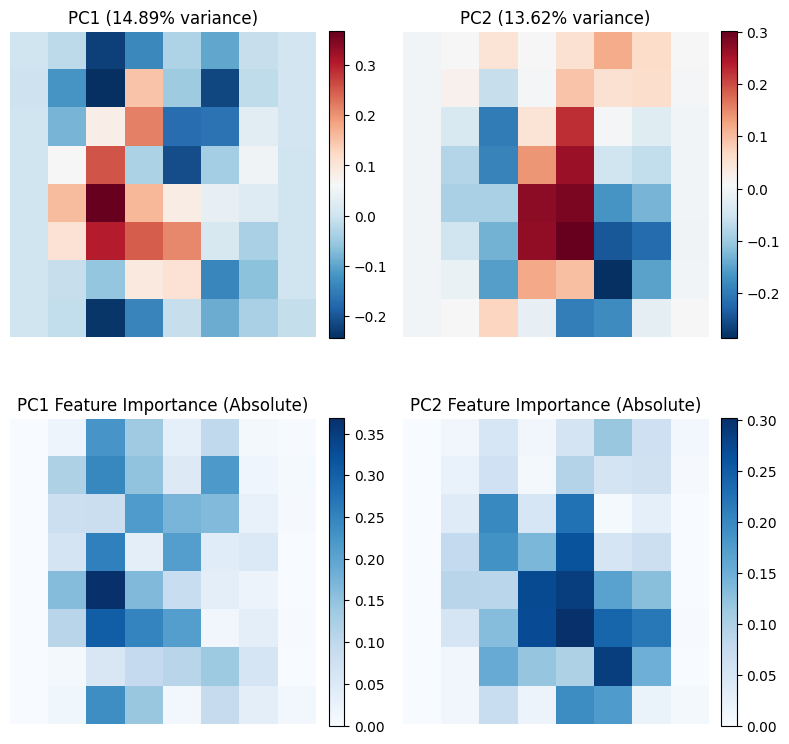

Interpretation:
- Bright regions show pixel positions most important for each PC
- PC1 and PC2 capture different aspects of digit variation


In [13]:
# Exercise 8: Interpreting PCA Components for Feature Importance
# Fit PCA with all 64 components
pca_all = PCA()
pca_all.fit(X)

# Extract principal components (loadings)
components = pca_all.components_  # shape: (64, 64)

# Examine first 2 components
print("Principal Component Analysis - Feature Importance\n")
print(f"Component shape: {components.shape}")
print(f"Explained variance by first 2 components: {sum(pca_all.explained_variance_ratio_[:2]):.4f}\n")

# Extract PC1 and PC2
pc1 = components[0]
pc2 = components[1]

# Find most important features (pixels) in PC1 and PC2
pc1_importance = np.abs(pc1)
pc2_importance = np.abs(pc2)

top_features_pc1 = np.argsort(pc1_importance)[-10:][::-1]
top_features_pc2 = np.argsort(pc2_importance)[-10:][::-1]

# Get top 5
top5_pc1 = np.argsort(pc1_importance)[-5:][::-1]
top5_pc2 = np.argsort(pc2_importance)[-5:][::-1]

print(f"Top 10 important features in PC1: {top_features_pc1}")
print(f"Top 10 important features in PC2: {top_features_pc2}\n")
print(f"Top 5 important features in PC1: {top5_pc1}")
print(f"Top 5 important features in PC2: {top5_pc2}\n")

# Visualize first 2 PCs as 8x8 images
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# PC1 component
ax = axes[0, 0]
pc1_image = pc1.reshape(8, 8)
im1 = ax.imshow(pc1_image, cmap='RdBu_r')
ax.set_title(f'PC1 ({pca_all.explained_variance_ratio_[0]:.2%} variance)')
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# PC2 component
ax = axes[0, 1]
pc2_image = pc2.reshape(8, 8)
im2 = ax.imshow(pc2_image, cmap='RdBu_r')
ax.set_title(f'PC2 ({pca_all.explained_variance_ratio_[1]:.2%} variance)')
ax.axis('off')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# PC1 absolute importance
ax = axes[1, 0]
pc1_abs_image = np.abs(pc1).reshape(8, 8)
im3 = ax.imshow(pc1_abs_image, cmap='Blues')
ax.set_title('PC1 Feature Importance (Absolute)')
ax.axis('off')
plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

# PC2 absolute importance
ax = axes[1, 1]
pc2_abs_image = np.abs(pc2).reshape(8, 8)
im4 = ax.imshow(pc2_abs_image, cmap='Blues')
ax.set_title('PC2 Feature Importance (Absolute)')
ax.axis('off')
plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Bright regions show pixel positions most important for each PC")
print("- PC1 and PC2 capture different aspects of digit variation")

In [14]:
### BEGIN TESTS
assert pc1.shape == (64,)
assert pc2.shape == (64,)
assert len(top5_pc1) == 5
assert len(top5_pc2) == 5
assert np.all(np.abs(pc1) >= 0)
assert np.all(np.abs(pc2) >= 0)
### END TESTS

### Questions
1. Which pixel features contribute most to the first principal component?  
2. How does the second principal component differ in terms of pixel contributions compared to the first?  
3. Why might some pixels have near-zero loadings?